In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
from aquarel import load_theme
import numpy as np

df = pd.read_csv("../data/processed/employee_attrition_processed.csv")
df.head()

,Age,Gender,Marital Status,Department,Job Role,Job Level,Monthly Income,Hourly Rate,Years At Company,Years In Current Role,...,Overtime,Project Count,Average Hours Worked Per Week,Absenteeism,Work Environment Satisfaction,Relationship With Manager,Job Involvement,Distance From Home,Number Of Companies Worked,Attrition
0,58,Female,Married,IT,Manager,1,15488,28,15,4,...,No,6,54,17,4,4,4,20,3,No
1,48,Female,Married,Sales,Assistant,5,13079,28,6,9,...,Yes,2,45,1,4,1,2,25,2,No
2,34,Male,Married,Marketing,Assistant,1,13744,24,24,14,...,Yes,6,34,2,3,4,4,45,3,No
3,27,Female,Divorced,Marketing,Manager,1,6809,26,10,8,...,No,9,48,18,2,3,1,35,3,No
4,40,Male,Divorced,Marketing,Executive,1,10206,52,29,10,...,No,3,33,0,4,1,3,44,3,No


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            1000 non-null   int64
 1   Gender                         1000 non-null   str  
 2   Marital Status                 1000 non-null   str  
 3   Department                     1000 non-null   str  
 4   Job Role                       1000 non-null   str  
 5   Job Level                      1000 non-null   int64
 6   Monthly Income                 1000 non-null   int64
 7   Hourly Rate                    1000 non-null   int64
 8   Years At Company               1000 non-null   int64
 9   Years In Current Role          1000 non-null   int64
 10  Years Since Last Promotion     1000 non-null   int64
 11  Work Life Balance              1000 non-null   int64
 12  Job Satisfaction               1000 non-null   int64
 13  Performance Rating            

## Attrition Overview

In [8]:
# set the theme first
theme = load_theme("arctic_dark")
theme.apply()

How common is attrition? Is the dataset imbalanced?

In [9]:
df.Attrition.value_counts()

Attrition
No     811
Yes    189
Name: count, dtype: int64

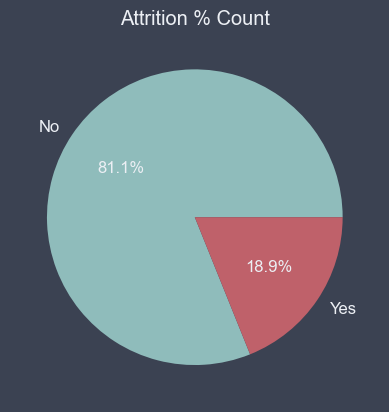

In [ ]:
attrition_counts = df.Attrition.value_counts(normalize=True)

plt.pie(attrition_counts.values, labels=attrition_counts.index, autopct="%1.1f%%")
plt.title("Attrition % Count")
plt.show()

## Demographics vs Attrition

Do younger employees leave more?

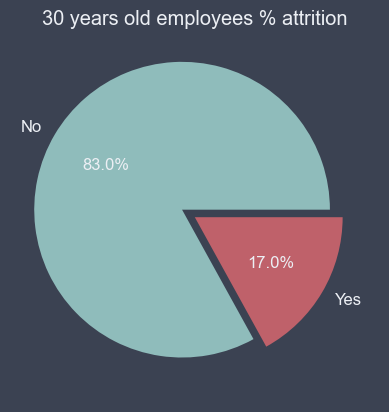

In [11]:
min_age, max_age = df.Age.min(), df.Age.max() # 20 and 59, respectively

# consider younger as <= 30 years old
younger_employees_df = df[df.Age <= 30]
younger_employees_attritions = younger_employees_df.Attrition.value_counts(normalize=True)

plt.pie(younger_employees_attritions.values, labels=younger_employees_attritions.index, autopct="%1.1f%%", explode=(0.1, 0))
plt.title("30 years old employees % attrition")
plt.show()

Does gender affect attrition?

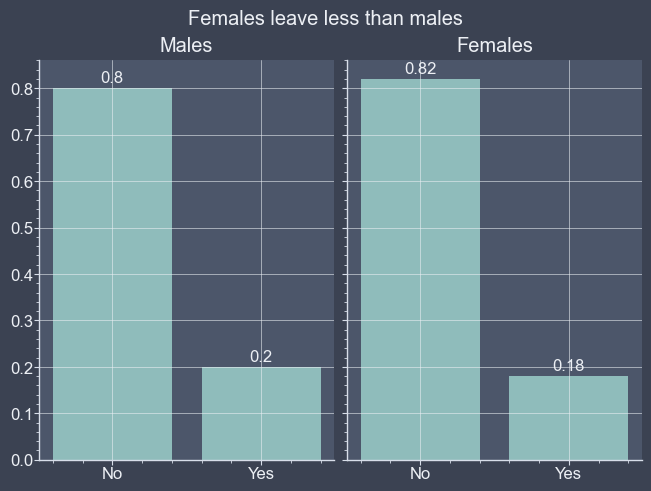

In [ ]:
male_gender_attritions = df[df.Gender == "Male"].Attrition.value_counts(normalize=True).round(2)
female_gender_attritions = df[df.Gender == "Female"].Attrition.value_counts(normalize=True).round(2)

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True, sharey=True)

male_bar_chart = axes[0].bar(male_gender_attritions.index, male_gender_attritions.values)
axes[0].bar_label(male_bar_chart, padding=2)
axes[0].set_title("Males")
female_bar_chart = axes[1].bar(female_gender_attritions.index, female_gender_attritions.values)
axes[1].bar_label(female_bar_chart, padding=2)
axes[1].set_title("Females")
plt.suptitle("Females leave less than males")
plt.show()

## Salary And Compensation

Does lower income increase attrition?

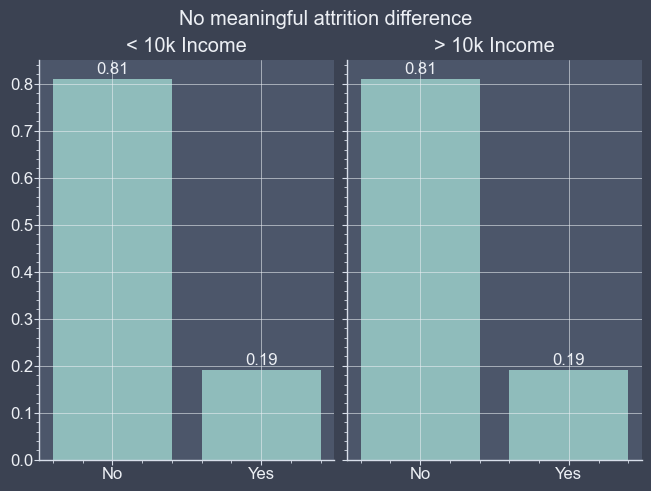

In [13]:
income_stats = df["Monthly Income"].agg(["min", "max"]) # min. is 3001, max. 19999

incomes_less_ten_thousands_attritions = df[df["Monthly Income"] < 10000].Attrition.value_counts(normalize=True).round(2)
incomes_more_ten_thousands_attritions = df[df["Monthly Income"] >= 1000].Attrition.value_counts(normalize=True).round(2)

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True, sharey=True)

incomes_less_ten_thousands_bar_chart = axes[0].bar(incomes_less_ten_thousands_attritions.index, incomes_less_ten_thousands_attritions.values)
axes[0].bar_label(incomes_less_ten_thousands_bar_chart, padding=2)
axes[0].set_title("< 10k Income")
incomes_more_ten_thousands_bar_chart = axes[1].bar(incomes_more_ten_thousands_attritions.index, incomes_more_ten_thousands_attritions.values)
axes[1].bar_label(incomes_more_ten_thousands_bar_chart, padding=2)
axes[1].set_title("> 10k Income")
plt.suptitle("No meaningful attrition difference")
plt.show()

Does hourly rate matter?

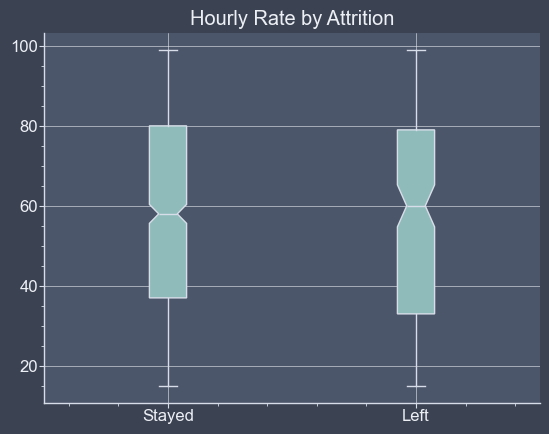

In [14]:
plt.boxplot([
    df[df.Attrition == "No"]["Hourly Rate"],
    df[df.Attrition == "Yes"]["Hourly Rate"]
], tick_labels=["Stayed", "Left"], patch_artist=True, notch=True)

plt.title("Hourly Rate by Attrition")
plt.show()

## Overtime And Workload

Does overtime increase attrition?

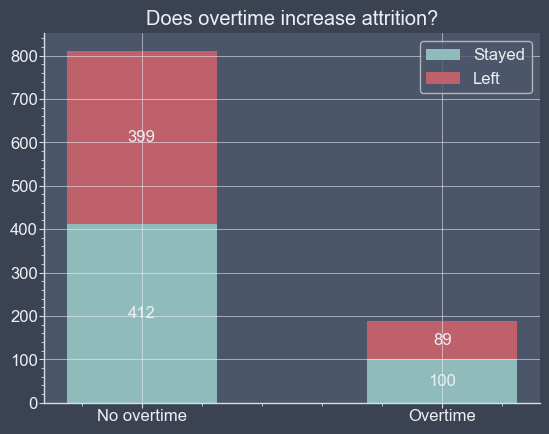

In [ ]:
overtime_groups = df.groupby("Overtime").Attrition.value_counts()
groups = ("No overtime", "Overtime")
group_counts = {
    "Stayed": np.array(overtime_groups.loc["No"]),
    "Left": np.array(overtime_groups.loc["Yes"]),
}
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(2)

for attrition, group_count in group_counts.items():
    p = ax.bar(groups, group_count, width, label=attrition, bottom=bottom)
    bottom += group_count
    ax.bar_label(p, label_type="center")

plt.legend()
plt.title("Does overtime increase attrition?")
plt.show()

Does project count affect attrition?

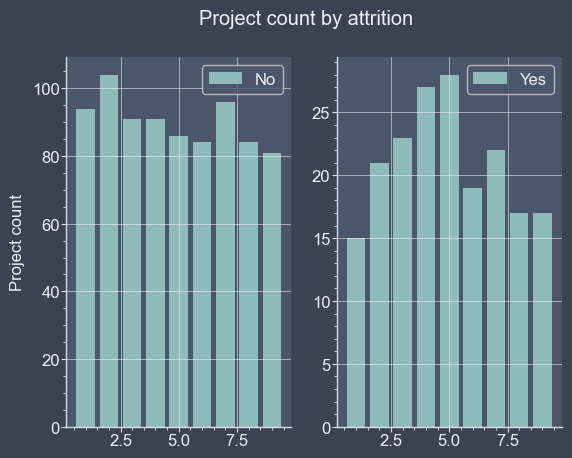

In [16]:
project_count_attritions = df.groupby("Attrition")["Project Count"].value_counts().sort_values()

fig, axes = plt.subplots(nrows=1, ncols=2)

axes[0].bar(project_count_attritions.loc["No"].index, project_count_attritions.loc["No"].values, label="No")
axes[0].set_ylabel("Project count")
axes[0].legend()
axes[1].bar(project_count_attritions.loc["Yes"].index, project_count_attritions.loc["Yes"].values, label="Yes")
axes[1].legend()
plt.suptitle("Project count by attrition")
plt.show()

In [17]:
project_attrition = pd.crosstab(df["Project Count"], df.Attrition, normalize="index")
project_attrition

Attrition,No,Yes
Project Count,,
1,0.862385,0.137615
2,0.832000,0.168000
3,0.798246,0.201754
4,0.771186,0.228814
5,0.754386,0.245614
6,0.815534,0.184466
7,0.813559,0.186441
8,0.831683,0.168317
9,0.826531,0.173469


## Satisfaction Analysis

Do dissatisfied employees leave more?

In [18]:
satisfaction_attrition = pd.crosstab(df["Job Satisfaction"], df.Attrition, normalize="index")
satisfaction_attrition

Attrition,No,Yes
Job Satisfaction,,
1,0.804469,0.195531
2,0.817680,0.182320
3,0.832432,0.167568
4,0.813636,0.186364
5,0.791489,0.208511


Does work-life balance matter?

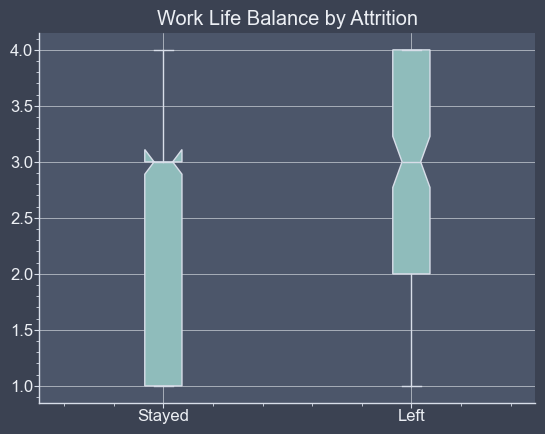

In [19]:
plt.boxplot([
    df[df.Attrition == "No"]["Work Life Balance"],
    df[df.Attrition == "Yes"]["Work Life Balance"]
], tick_labels=["Stayed", "Left"], patch_artist=True, notch=True)

plt.title("Work Life Balance by Attrition")
plt.show()

## Career Progression

Do employees leave after long periods without promotion?

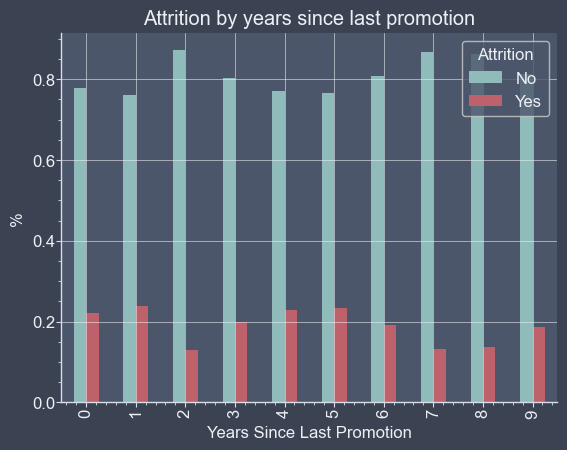

In [ ]:
promotion_attrition = pd.crosstab(df["Years Since Last Promotion"], df.Attrition, normalize="index")
promotion_attrition.plot(kind="bar")
plt.title("Attrition by years since last promotion")
plt.ylabel("%")
plt.show()

Do newer employees leave more?

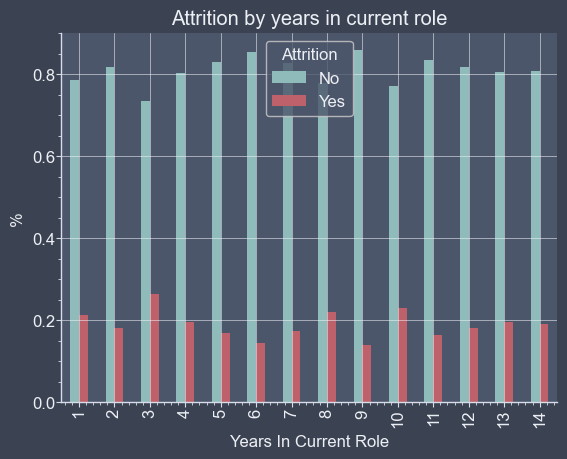

In [21]:
years_in_role_attrition = pd.crosstab(df["Years In Current Role"], df.Attrition, normalize="index")
years_in_role_attrition.plot(kind="bar")
plt.title("Attrition by years in current role")
plt.ylabel("%")
plt.show()

## Department And Job Role Analysis

Which departments have the highest attrition?

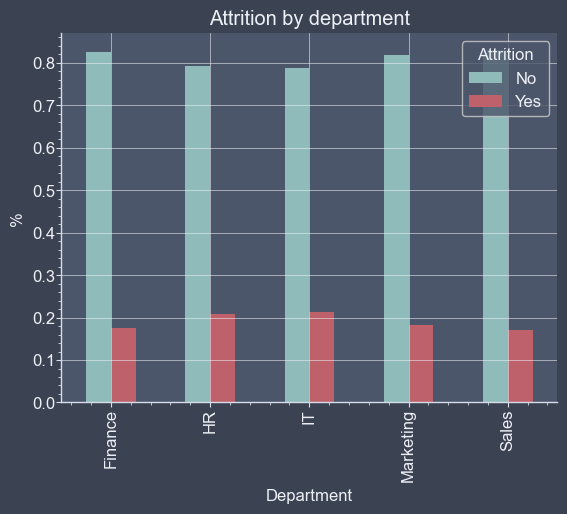

In [ ]:
department_attrition = pd.crosstab(df["Department"], df.Attrition, normalize="index")
department_attrition.plot(kind="bar")
plt.title("Attrition by department")
plt.ylabel("%")
plt.show()

Which roles are most unstable?

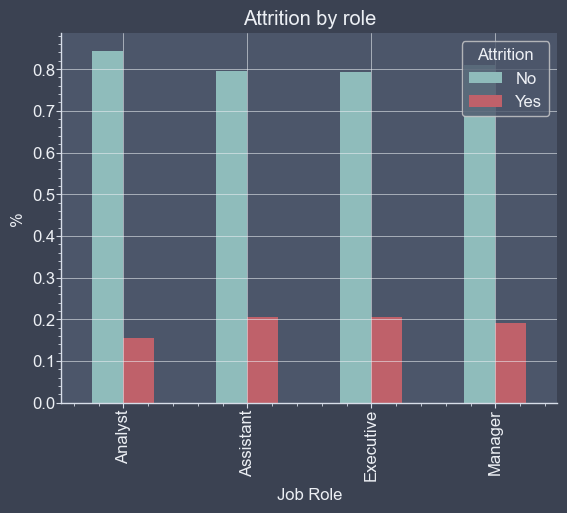

In [23]:
role_attrition = pd.crosstab(df["Job Role"], df.Attrition, normalize="index")
role_attrition.plot(kind="bar")
plt.title("Attrition by role")
plt.ylabel("%")
plt.show()

## Correlation Analysis

Which numerical variables correlate with attrition?

In [24]:
df.Attrition = df.Attrition.map({"Yes": 1, "No": 0})
numeric_vars_corr = df.corr(numeric_only=True).Attrition.sort_values()

numeric_vars_corr

Training Hours Last Year        -0.056096
Years Since Last Promotion      -0.047877
Performance Rating              -0.039784
Job Involvement                 -0.037339
Distance From Home              -0.027623
Years In Current Role           -0.013969
Hourly Rate                     -0.009848
Number Of Companies Worked      -0.001095
Work Environment Satisfaction    0.001459
Project Count                    0.009278
Job Level                        0.010231
Monthly Income                   0.011921
Job Satisfaction                 0.013362
Relationship With Manager        0.015953
Years At Company                 0.022873
Age                              0.029221
Work Life Balance                0.033404
Absenteeism                      0.043621
Average Hours Worked Per Week    0.047117
Attrition                        1.000000
Name: Attrition, dtype: float64

## Distribution Analysis

Are hours worked normally distributed?

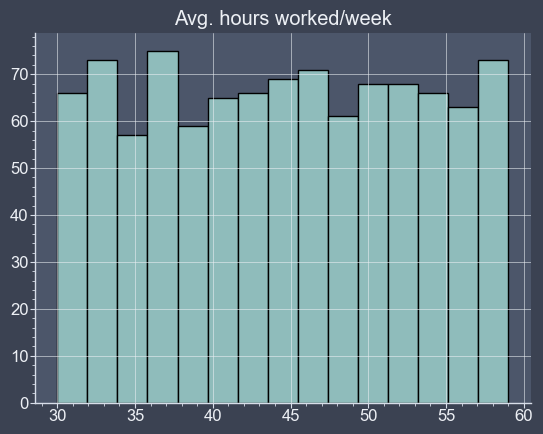

In [25]:
plt.hist(df["Average Hours Worked Per Week"], edgecolor="black", bins=15)
plt.title("Avg. hours worked/week")
plt.show()

In [26]:
hours_worked_stats = df["Average Hours Worked Per Week"].agg(["mean", "min", "max", "median", np.std])
hours_worked_stats

mean      44.553000
min       30.000000
max       59.000000
median    45.000000
std        8.699839
Name: Average Hours Worked Per Week, dtype: float64

Are promotions rare?

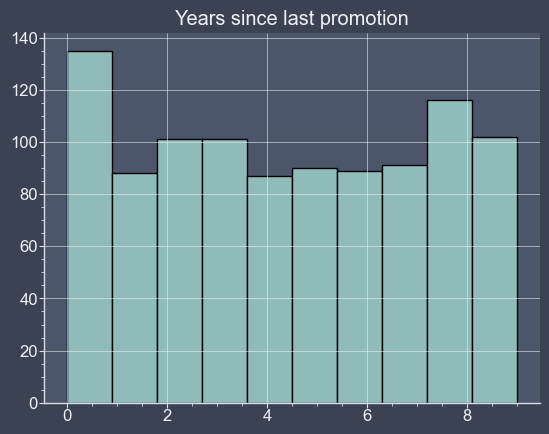

In [27]:
plt.hist(df["Years Since Last Promotion"], edgecolor="black")
plt.title("Years since last promotion")
plt.show()

In [28]:
# percentage of employees with long waits
(df["Years Since Last Promotion"] >= 5).mean()

np.float64(0.488)

## Exploratory Data Analysis (EDA) Conclusions

1. The dataset is heavily skewed towards people who stay in their role, represented by 81.1% in the data.
2. Younger employees (those who are less than 30 years old) don’t leave more compared to older ones. In fact, the percentage of those who stay is 83%.
3. Gender doesn’t affect attrition meaningfully. The % of males and females that don’t leave is almost equal, 80% and 82%, respectively.
4. Attrition rates appeared similar across lower and higher salary groups in this dataset. Those with less than 10k income stay in their role 81% of the times, like the ones with more than 10k salary.
5. Hourly rates showed very similar distributions between employees who stayed and those who left, suggesting compensation alone may not strongly influence attrition. 
6. People who handle more projects don’t leave more. The data shows people tend to leave more from 2 to 5 projects, but then the percentage decreases until 9.
7. Unexpectedly, employees with higher job satisfaction scores showed slightly higher attrition rates, though the difference was very small and may reflect noise within the dataset. 
8. Higher work-life balance scores were associated with slightly higher attrition in the dataset, though the difference was weak and may not represent a meaningful real-world relationship.
9. Employees who haven’t received a promotion for 9 years leave in the same proportion, compared to those who have just started at a company. There is no clear trend that shows less proportion would mean higher attrition.
10. The data suggests Finance jobs leave less compared to HR and IT jobs. The same is true for Marketing and Sales jobs.
11. There is no clear correlation between the numeric variables in the dataset and attrition. For instance, the correlation between hourly rate is -0.009 indicating that it doesn’t have a huge influence on whether a person stays or leaves, though it is slightly negative.
12. Average hours worked/week values don’t follow a bell curve, indicated by the mean of 44.6 and a median of 45. The standard deviation confirms the data doesn’t have extreme values, at 8.7.

